Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [6]:
df = pd.read_csv("/content/teachingratings_extracted.csv")

df.head()

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1,0,1,1,0,1,1,1
1,yes,36,female,more,0.289916,3.7,upper,yes,yes,86,125,1,0,1,1,0,1,1,1
2,yes,36,female,more,0.289916,3.6,upper,yes,yes,76,125,1,0,1,1,0,1,1,1
3,yes,36,female,more,0.289916,4.4,upper,yes,yes,77,123,1,1,1,1,0,1,1,1
4,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2,0,0,0,0,1,1,1


Q1. Is the teachers' rating data time series or cross-sectional?

In [7]:
# Display column names
print(df.columns.tolist())

# Check whether there is a date/time variable
print("\nData types:")
print(df.dtypes)

['minority', 'age', 'gender', 'credits', 'beauty', 'eval', 'division', 'native', 'tenure', 'students', 'allstudents', 'prof', 'PrimaryLast', 'vismin', 'female', 'single_credit', 'upper_division', 'English_speaker', 'tenured_prof']

Data types:
minority            object
age                  int64
gender              object
credits             object
beauty             float64
eval               float64
division            object
native              object
tenure              object
students             int64
allstudents          int64
prof                 int64
PrimaryLast          int64
vismin               int64
female               int64
single_credit        int64
upper_division       int64
English_speaker      int64
tenured_prof         int64
dtype: object


It represents observations of professors/courses rather than observations recorded sequentially over time. Although the same professor can appear in multiple rows because they have multiple course evaluations, there is no time dimension.

Q2. Find the mean, median, minimum and maximum values for students

In [8]:
mean_students = df['students'].mean()
median_students = df['students'].median()
min_students = df['students'].min()
max_students = df['students'].max()

print("Mean:", mean_students)
print("Median:", median_students)
print("Minimum:", min_students)
print("Maximum:", max_students)

Mean: 36.64192139737991
Median: 23.0
Minimum: 5
Maximum: 380


Q3. Produce the descriptive statistics table

In [9]:
# Descriptive statistics for numerical variables
df.describe()

,age,beauty,eval,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
count,458.000000,458.000000,458.000000,458.000000,458.000000,458.000000,458.000000,458.000000,458.000000,458.000000,458.000000,458.000000,458.000000
mean,48.323144,-0.001213,3.998035,36.641921,55.268559,45.379913,0.200873,0.139738,0.425764,0.058952,0.661572,0.938865,0.781659
std,9.816052,0.787657,0.552948,45.125434,75.364874,27.529491,0.401092,0.347094,0.494999,0.235792,0.473692,0.239840,0.413572
min,29.000000,-1.450494,2.100000,5.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,-0.656269,3.600000,15.000000,19.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,48.000000,-0.068014,4.000000,23.000000,29.000000,44.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,57.000000,0.547945,4.400000,40.000000,60.000000,70.750000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,73.000000,1.970023,5.000000,380.000000,581.000000,94.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
descriptive_stats = df.describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
age,458.0,48.323144,9.816052,29.000000,42.000000,48.000000,57.000000,73.000000
beauty,458.0,-0.001213,0.787657,-1.450494,-0.656269,-0.068014,0.547945,1.970023
eval,458.0,3.998035,0.552948,2.100000,3.600000,4.000000,4.400000,5.000000
students,458.0,36.641921,45.125434,5.000000,15.000000,23.000000,40.000000,380.000000
allstudents,458.0,55.268559,75.364874,8.000000,19.000000,29.000000,60.000000,581.000000
prof,458.0,45.379913,27.529491,1.000000,20.000000,44.000000,70.750000,94.000000
PrimaryLast,458.0,0.200873,0.401092,0.000000,0.000000,0.000000,0.000000,1.000000
vismin,458.0,0.139738,0.347094,0.000000,0.000000,0.000000,0.000000,1.000000
female,458.0,0.425764,0.494999,0.000000,0.000000,0.000000,1.000000,1.000000
single_credit,458.0,0.058952,0.235792,0.000000,0.000000,0.000000,0.000000,1.000000


Q4. Create a histogram of the beauty variable

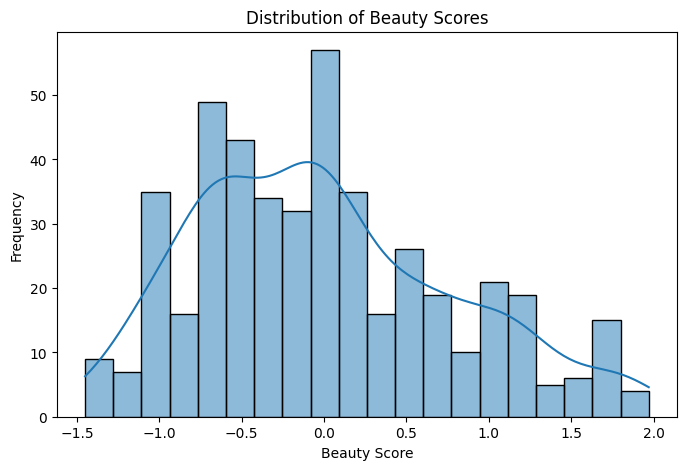

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['beauty'], bins=20, kde=True)

plt.title('Distribution of Beauty Scores')
plt.xlabel('Beauty Score')
plt.ylabel('Frequency')

plt.show()

In [12]:
print("Skewness:", df['beauty'].skew())

Skewness: 0.5047636965025605


The beauty scores are centered close to 0. The distribution is slightly positively/right skewed, meaning there is a somewhat longer tail toward higher beauty scores. It is not extremely skewed, so the distribution is reasonably balanced overall.

Q5. Does average beauty score differ by gender?

In [13]:
gender_beauty = df.groupby('gender')['beauty'].agg(
    Mean='mean',
    Standard_Deviation='std',
    Count='count'
)

gender_beauty.round(3)

,Mean,Standard_Deviation,Count
gender,,,
female,0.116,0.818,195
male,-0.088,0.754,263


Female instructors have an average beauty score of approximately 0.116, whereas male instructors have an average beauty score of approximately -0.088.

Therefore, yes, the average beauty score differs by gender in this dataset. Female instructors have a somewhat higher average beauty score than male instructors

Optional visualization

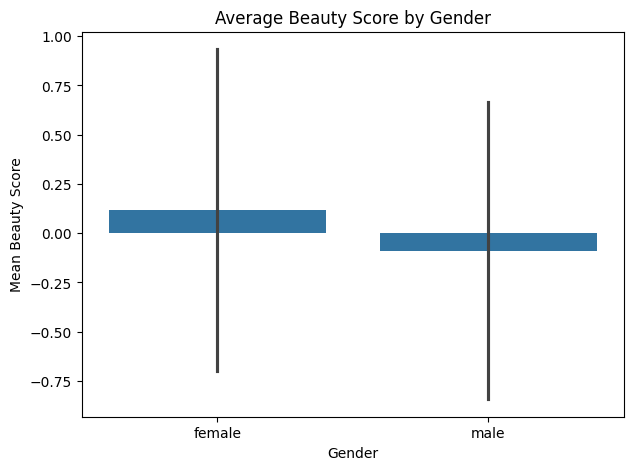

In [14]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='gender',
    y='beauty',
    errorbar='sd'
)

plt.title('Average Beauty Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Mean Beauty Score')

plt.show()

Q6. Calculate the percentage of males and females that are tenured professors

In [15]:
print(df['tenure'].value_counts())

tenure
yes    358
no     100
Name: count, dtype: int64


In [16]:
tenure_gender = pd.crosstab(
    df['gender'],
    df['tenure'],
    normalize='index'
) * 100

tenure_gender.round(2)

tenure,no,yes
gender,,
female,25.64,74.36
male,19.01,80.99


Interpretation

Approximately:

74.36% of female instructors are tenured
80.99% of male instructors are tenured

Therefore, the percentage of tenured professors does differ by gender in this dataset. The proportion of tenured male instructors is higher than the proportion of tenured female instructors.